<a href="https://colab.research.google.com/github/tiwalolui/Football-stats-analyzer/blob/main/Football-performance-analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       player_name         club  country position  age  matches  minutes  \
0   Victor Osimhen       Napoli  Nigeria       ST   25       28     2300   
1      Bukayo Saka      Arsenal  England       RW   23       30     2500   
2  Jude Bellingham  Real Madrid  England       CM   21       29     2400   
3  Kevin De Bruyne     Man City  Belgium       CM   33       22     1800   
4    Mohamed Salah    Liverpool    Egypt       RW   32       31     2700   

   goals  assists  shots  passes  tackles  yellow_cards  red_cards  
0     18        4     85     620       20             5          0  
1     14        9     90    1400       35             4          0  
2     16        7     75    1600       55             6          0  
3      8       15     60    1700       30             3          0  
4     19       10    110    1000       25             2          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 14 columns):
 #   Column        Non-Null

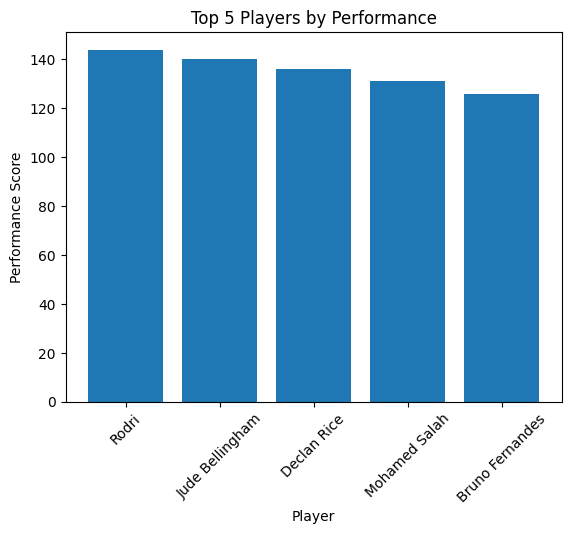

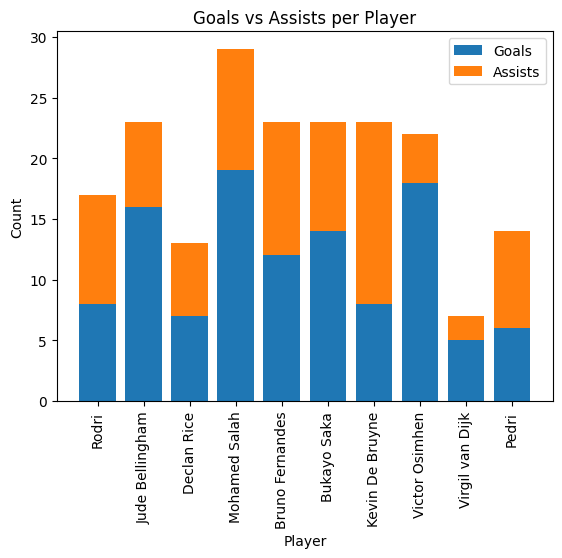

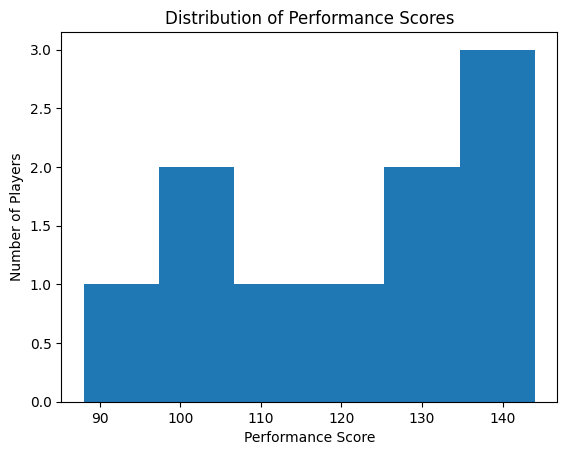

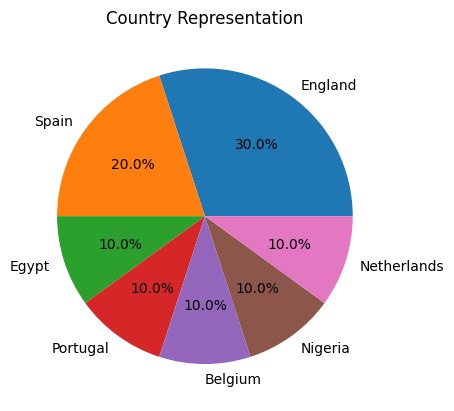

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. CREATE DATA (STUDENT-GENERATED)
# ================================
data = {
    "player_name": [
        "Victor Osimhen", "Bukayo Saka", "Jude Bellingham",
        "Kevin De Bruyne", "Mohamed Salah", "Pedri",
        "Bruno Fernandes", "Declan Rice", "Virgil van Dijk", "Rodri"
    ],
    "club": [
        "Napoli", "Arsenal", "Real Madrid",
        "Man City", "Liverpool", "Barcelona",
        "Man United", "Arsenal", "Liverpool", "Man City"
    ],
    "country": [
        "Nigeria", "England", "England",
        "Belgium", "Egypt", "Spain",
        "Portugal", "England", "Netherlands", "Spain"
    ],
    "position": [
        "ST", "RW", "CM",
        "CM", "RW", "CM",
        "CM", "CDM", "CB", "CDM"
    ],
    "age": [25, 23, 21, 33, 32, 22, 30, 26, 33, 28],
    "matches": [28, 30, 29, 22, 31, 26, 34, 33, 32, 34],
    "minutes": [2300, 2500, 2400, 1800, 2700, 2100, 2900, 2950, 2880, 3000],
    "goals": [18, 14, 16, 8, 19, 6, 12, 7, 5, 8],
    "assists": [4, 9, 7, 15, 10, 8, 11, 6, 2, 9],
    "shots": [85, 90, 75, 60, 110, 50, 95, 55, 20, 65],
    "passes": [620, 1400, 1600, 1700, 1000, 1800, 1900, 2000, 1800, 2100],
    "tackles": [20, 35, 55, 30, 25, 40, 45, 90, 75, 85],
    "yellow_cards": [5, 4, 6, 3, 2, 5, 8, 7, 4, 6],
    "red_cards": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
}

df = pd.DataFrame(data)

# ================================
# 2. BASIC INSPECTION
# ================================
print(df.head())
print(df.info())
print(df.describe())

# ================================
# 3. DATA CLEANING
# ================================
df = df[df["matches"] >= 5].reset_index(drop=True)

# ================================
# 4. FEATURE ENGINEERING
# ================================
df["goals_per_match"] = df["goals"] / df["matches"]
df["assists_per_match"] = df["assists"] / df["matches"]
df["contribution"] = df["goals"] + df["assists"]

# Performance score rule
df["performance_score"] = (
    df["goals"] * 4 +
    df["assists"] * 3 +
    df["tackles"] * 1
)

# ================================
# 5. RANKING PLAYERS
# ================================
df = df.sort_values("performance_score", ascending=False).reset_index(drop=True)
df["rank"] = df.index + 1

print("\nFINAL RANKED TABLE:")
print(df[[
    "rank", "player_name", "club", "country",
    "goals", "assists", "tackles", "performance_score"
]])

top_5 = df.head(5)

# ================================
# 6. STATISTICAL ANALYSIS
# ================================
print("\nMEAN GOALS:", df["goals"].mean())
print("MEAN ASSISTS:", df["assists"].mean())
print("MEAN PERFORMANCE SCORE:", df["performance_score"].mean())

print("\nAVERAGE PERFORMANCE BY CLUB:")
print(df.groupby("club")["performance_score"].mean().sort_values(ascending=False))

print("\nPLAYER COUNT BY COUNTRY:")
print(df["country"].value_counts())

# ================================
# 7. VISUALIZATIONS
# ================================

# Top 5 players
plt.figure()
plt.bar(top_5["player_name"], top_5["performance_score"])
plt.xlabel("Player")
plt.ylabel("Performance Score")
plt.title("Top 5 Players by Performance")
plt.xticks(rotation=45)
plt.show()

# Goals vs Assists
plt.figure()
plt.bar(df["player_name"], df["goals"], label="Goals")
plt.bar(df["player_name"], df["assists"], bottom=df["goals"], label="Assists")
plt.xlabel("Player")
plt.ylabel("Count")
plt.title("Goals vs Assists per Player")
plt.xticks(rotation=90)
plt.legend()
plt.show()

# Performance distribution
plt.figure()
plt.hist(df["performance_score"], bins=6)
plt.xlabel("Performance Score")
plt.ylabel("Number of Players")
plt.title("Distribution of Performance Scores")
plt.show()

# Country representation
country_counts = df["country"].value_counts()
plt.figure()
plt.pie(country_counts.values, labels=country_counts.index, autopct="%1.1f%%")
plt.title("Country Representation")
plt.show()